<a href="https://colab.research.google.com/github/sn0wsally/self-study-Spatial-Transcriptomics/blob/main/base_study/mouse_brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scanpy squidpy leidenalg

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of dask[array,dataframe] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━

In [ ]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pandas as pd
import warnings

In [ ]:
# ignore warning messages
warnings.filterwarnings("ignore")

## Purpose

Traditional histology identifies each tissue through microscopical observation of H&E dyed tissue images. However, this multi-modal model could flip the traditional order of diagnosis. The model is asked to cluster transcriptome from each spot without histological images. The clustered result can be marked back on actual histological area, allowing comparison between actual histological structure and the predicted groups from genomic data.

## What does each step do in the code?
### 1. Preprocessing & Quality control (QC)
Eliminate damaged tissues and spots (e.g. abnormally high rate of mitrochondria, significantly low number of genes) from the dataset to improve reliability of the analysis.
### 2. PCA & UMAP
Reduce dimensionality from 20,000 genomic data to 2D. This reduces data noise and extract major features.
### 3. **Unsupervised Clustering** - Leiden/Louvain
Without using structural information (coordinal/geometrical data), cluster spots solely according to the genomic implementation pattern similarity.
### 4. Spatial Mapping
Apply the cluster IDs onto the Spatial coordinates to visualize the predicted results.

In [ ]:
def run_spatial_analysis():
    print("🚀 1. Data loading... (Mouse Brain Visium)")
    # 10x Genomics Visium Mouse Brain sample data offered by Squidpy
    adata = sq.datasets.visium_hne_adata()

    # Data basic info
    print(f"📊 Data info: {adata.n_obs} spots, {adata.n_vars} genes")

    # --- Preprocessing ---
    print("⚙️ 2. Data preprocessing...")

    # 1) Calculate mitochondrion gene ratio (Quality Control)
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

    # 2) Filter (delete the spots without significant amount of gene expression)
    sc.pp.filter_cells(adata, min_counts=500)
    sc.pp.filter_genes(adata, min_cells=10)

    # 3) Normalization
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # 4) HVG (high variable gene) selection
    sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

    # --- Dimension Reduction & Clustering ---
    print("🧮 3. PCA, UMAP & Clustering...")

    # PCA
    sc.pp.pca(adata)

    # Neighbor Graph
    sc.pp.neighbors(adata)

    # UMAP (dimension reduction for visualization)
    sc.tl.umap(adata)

    # Leiden Clustering (cluster the spots according to gene expression patterns)
    sc.tl.leiden(adata, resolution=0.8) # resolution control -> the number of clusters

    # --- Visualization & Saving ---
    print("🎨 4. Result Visualization & Saving...")

    # setting to save image
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Spatial Plot (cluster mapping on the actual image)
    # img_alpha: transparency
    sq.pl.spatial_scatter(
        adata,
        color="leiden",
        ax=axs[0],
        title="Spatial Clustering (Mouse Brain)",
        img_alpha=0.5
    )

    # 2. UMAP Plot (non-linear dimension reduction)
    sc.pl.umap(
        adata,
        color="leiden",
        ax=axs[1],
        title="UMAP Projection",
        show=False
    )

    # Save the result
    plt.tight_layout()
    output_filename = "spatial_analysis_result.png"
    plt.savefig(output_filename, dpi=300)
    print(f"Analysis completed ✅ The result is saved as '{output_filename}'.")

# if __name__ == "__main__":
#     run_spatial_analysis()

## Result

🚀 1. Data loading... (Mouse Brain Visium)
INFO     Downloading visium_hne_adata.h5ad from                                                                    
         https://exampledata.scverse.org/squidpy/figshare/visium_hne_adata.h5ad                                    


  0%|                                               | 0.00/329M [00:00<?, ?B/s]

📊 Data info: 2688 spots, 18078 genes
⚙️ 2. Data preprocessing...
🧮 3. PCA, UMAP & Clustering...
🎨 4. Result Visualization & Saving...
Analysis completed ✅ The result is saved as 'spatial_analysis_result.png'.


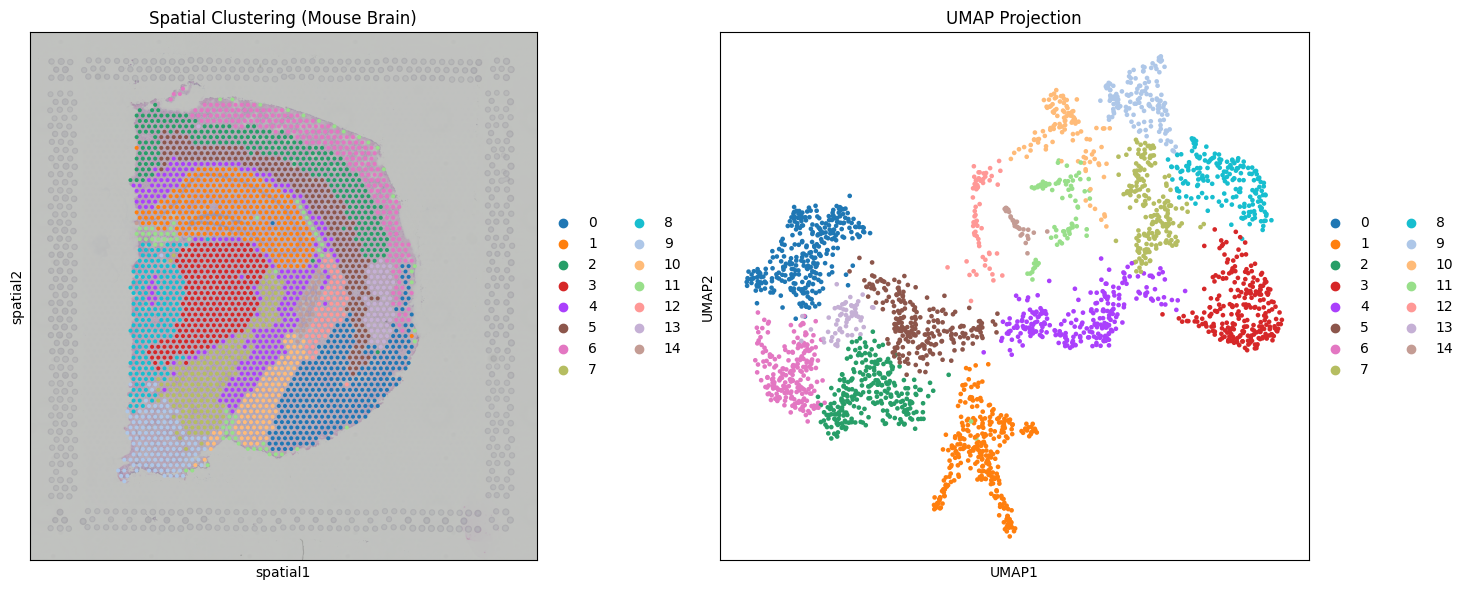

In [ ]:
run_spatial_analysis()

## Discussion

This baseline analysis of the Mouse Brain Spatial Transcriptomics (ST) data yields three critical insights that serve as the foundation for the upcoming Deep Learning pipeline:

### 1. Transcriptome Perfectly Mirrors Morphology
The comparison between UMAP and Spatial Clustering demonstrates a profound biological principle: **tissue architecture is fundamentally encoded in the transcriptome.** Without any spatial coordinates provided to the Leiden algorithm, the unsupervised clustering of gene expression profiles naturally reconstructed the exact anatomical layers of the mouse brain (e.g., Cortical layers, Hippocampus).

### 2. Statistical Validation of Spatial Heterogeneity
The Moran's I spatial autocorrelation analysis successfully identified highly Spatially Variable Genes (SVGs) such as *Pcp4*, *Hpcal1*, and *Mbp*. This provides robust statistical evidence that these marker genes are not randomly distributed but are distinctly localized to specific functional regions of the tissue.

### 3. Establishing the Ground Truth ($Y$) for Deep-ST
Most importantly, this study establishes a highly reliable **Ground Truth ($Y$)** for the core Computer Vision project. Since we have proven that distinct transcriptomic clusters have distinct, observable histological locations, the fundamental premise of our main project is validated: **A deep learning vision model (ResNet/ViT) can be trained to predict these invisible transcriptomic clusters directly from the morphological patterns in standard H&E image patches ($X$).**
